In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.sparse import hstack
import plotly.express as px

In [2]:
df = pd.read_csv("/content/googleplaystore.csv")

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df.shape



(10841, 13)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  int64  
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10841 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10839 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.1+ MB


In [5]:
df.describe()

,Rating,Reviews
count,9367.000000,1.084100e+04
mean,4.191513,4.441119e+05
std,0.515735,2.927629e+06
min,1.000000,0.000000e+00
25%,4.000000,3.800000e+01
50%,4.300000,2.094000e+03
75%,4.500000,5.476800e+04
max,5.000000,7.815831e+07


In [6]:
df.isnull().sum()

,0
App,0
Category,1
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,0
Genres,1


## Data Cleaning

In [7]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

In [8]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [9]:
# Clean Installs (Remove symbols)

df['Installs'] = df['Installs'].str.replace('+','')
df['Installs'] = df['Installs'].str.replace(',','')
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

In [10]:
df['Price'] = df['Price'].str.replace('$','')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')


def convert_size(size):

    if 'M' in str(size):
        return float(size.replace('M','')) * 1000

    if 'K' in str(size):
        return float(size.replace('K',''))

    return np.nan

df['Size'] = df['Size'].apply(convert_size)

In [11]:
df = df.drop_duplicates(subset='App')

In [12]:
df['Rating'].fillna(df['Rating'].median(), inplace=True)

df = df.dropna(subset=['Type'])

/tmp/ipykernel_423/2397424474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].median(), inplace=True)


In [13]:
df = df.dropna(subset=['Category']) # small amount → easiest solution: drop it
df = df.dropna(subset=['Genres'])

In [14]:
df['Size'] = df.groupby('Category')['Size'].transform(
    lambda x: x.fillna(x.median())
)

In [15]:
df['Android Ver'].fillna(df['Android Ver'].mode()[0], inplace=True)

/tmp/ipykernel_423/304938070.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Android Ver'].fillna(df['Android Ver'].mode()[0], inplace=True)


In [16]:
df = df.drop(columns=['Current Ver'])

In [17]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [18]:
df.to_csv("clean_apps.csv", index=False)

## EDA

# Insight 1:
Communication, Tools, and Entertainment apps dominate the Play Store. These categories are highly competitive but also attract the most users.

In [19]:

top_categories = df['Category'].value_counts().reset_index()
top_categories.columns = ['Category', 'Count']

fig = px.bar(
    top_categories.head(5),
    x='Category',
    y='Count',
    text='Count',
    color='Count',
    color_continuous_scale='Blues',
    title=" Top 5 App Categories"
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Number of Apps",
    xaxis_tickangle=-45
)
fig.show()

# Insght 2:

which app categories provide the best user experience


In [69]:
category_rating = df.groupby("Category")["Rating"].mean().reset_index()

fig = px.bar(
    category_rating,
    x="Category",
    y="Rating",
    title="Average App Rating by Category",

)

fig.show()

# Insghts 3:

Free vs Paid Apps Distribution

In [44]:
type_count = df["Type"].value_counts().reset_index()
type_count.columns = ["Type", "Count"]

fig = px.pie(
    type_count,
    names="Type",
    values="Count",
    title="Free vs Paid Apps Distribution",
)

fig.show()

# Insight :
Installs by Category

In [61]:
fig = px.bar(
    installs_category,
    x="Category",
    y="Installs",
    title="Total Installs by Category",
    color_discrete_sequence=["#6A5ACD"]
)

fig.show()

# Insight: Reviews vs Average Rating by Category
High Reviews = High Market Demand

Categories with very large review counts indicate strong user engagement and large user bases. These categories dominate the Play Store market and typically contain highly popular apps.

Interpretation:
High review volume suggests these categories are high-demand markets with intense competition.

In [58]:
import pandas as pd

category_data = df.groupby("Category").agg({
    "Reviews": "sum",
    "Rating": "mean"
}).reset_index()

category_data = category_data.sort_values("Reviews", ascending=False).head(10)
import plotly.graph_objects as go

fig = go.Figure()

# Bar chart for Reviews
fig.add_trace(
    go.Bar(
        x=category_data["Category"],
        y=category_data["Reviews"],
        marker=dict(color="#FECB52"),
        name="Total Reviews"
    )
)

# Line chart for Rating
fig.add_trace(
    go.Scatter(
        x=category_data["Category"],
        y=category_data["Rating"],
        name="Average Rating",
        yaxis="y2",
        mode="lines+markers"
    )
)

fig.update_layout(
    title="App Reviews vs Average Rating by Category",
    xaxis_title="Category",
    yaxis=dict(title="Total Reviews"),
    yaxis2=dict(
        title="Average Rating",
        overlaying="y",
        side="right"
    ),
    legend_title="Metrics"
)

fig.show()

# Insight:
Some categories have fewer apps but higher ratings (e.g., Medical, Education).
Highly installed categories do not always have the highest ratings — opportunity for quality apps.

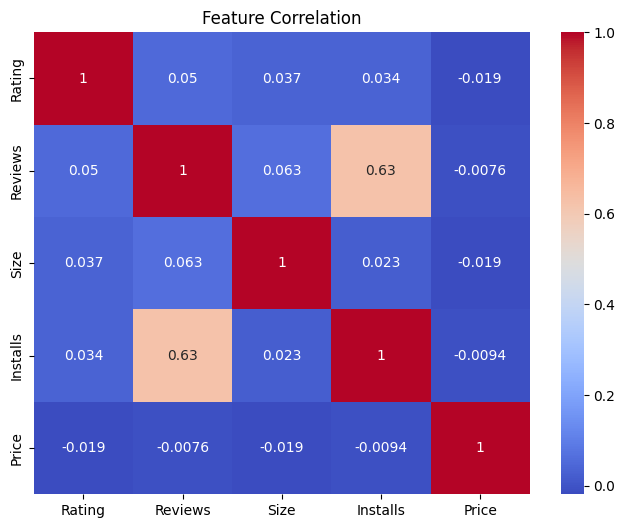

In [24]:
# Insight: Reviews strongly correlate with installs.

plt.figure(figsize=(8,6))

corr = df[['Rating','Reviews','Size','Installs','Price']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

## Feature Engineering

In [28]:
# Log transform installs
df['Log_Installs'] = np.log1p(df['Installs'])

In [29]:
# Engagement Score
df['Engagement'] = df['Reviews'] / df['Installs']

# Popularity Score

df['Popularity'] = df['Rating'] * np.log1p(df['Reviews'])



# Clustering Apps (Market Segments)

In [30]:
features = df[['Rating','Reviews','Installs','Price']]

scaler = StandardScaler()

X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=5)

df['Cluster'] = kmeans.fit_predict(X)

# Cluster Visualization



---
# used KMeans clustering on features like:
* Rating
* Reviews
* Installs
* Price

The need it:


Clustering is used for insights.
It tells :
- Which apps are highly popular
- Which apps are niche/high-rated but low installs
- Which apps are low engagement or low quality


It’s an unsupervised AI method to explore patterns in the app market.



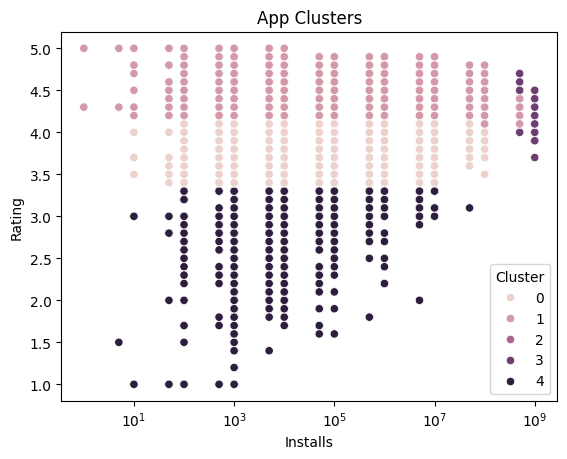

In [31]:
plt.figure()

sns.scatterplot(
    x=df['Installs'],
    y=df['Rating'],
    hue=df['Cluster']
)

plt.xscale('log')

plt.title("App Clusters")

plt.show()

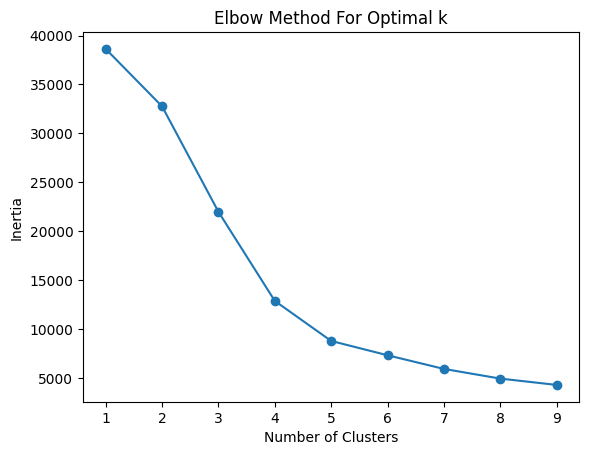

In [32]:
from sklearn.cluster import KMeans

inertia = []

K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method For Optimal k")

plt.show()

# Cluster 2

In [33]:
features = ['Rating','Reviews','Installs','Price']
X = df[features]

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Now cluster_centers_ has shape (3, 4) → matches your columns
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=features)
print(cluster_centers)

     Rating       Reviews      Installs         Price
0  4.191928  1.513818e+05  4.485431e+06  1.104445e+00
1  4.375000  9.852274e+06  5.000000e+08 -4.440892e-16
2  4.215000  2.001139e+07  1.000000e+09 -4.440892e-16


In [34]:
df['Cluster'] = kmeans.labels_

# Optional: map meaningful labels
cluster_labels = {0:'Paid Moderate', 1:'Popular Free', 2:'Top Free'}
df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

# Quick summary
df.groupby('Cluster_Label')[['Rating','Reviews','Installs','Price']].mean()

,Rating,Reviews,Installs,Price
Cluster_Label,,,,
Paid Moderate,4.191928,1.513818e+05,4.485431e+06,1.104445
Popular Free,4.375000,9.852274e+06,5.000000e+08,0.000000
Top Free,4.215000,2.001139e+07,1.000000e+09,0.000000


In [35]:
# After clustering in notebook
cluster_labels = {0:'Paid Moderate', 1:'Popular Free', 2:'Top Free'}
df['Cluster_Label'] = df['Cluster'].map(cluster_labels)

# Save with cluster
df.to_csv("clean_apps.csv", index=False)

# Recommendation System Content-Based Filteringusing TF-IDF + Cosine Similarity

# Create a Feature for Recommendation

In [36]:
df['text_features'] = (
    df['Category'] + " " +
    df['Genres'] + " " +
    df['Content Rating'] + " " +
    df['Type']
)

# TF-IDF Vectorization

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['text_features'])

# Numeric Features (Rating + Installs)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_features = scaler.fit_transform(
    df[['Rating','Log_Installs']]
)

# Combine TF-IDF + Numeric Features

In [39]:
from scipy.sparse import hstack

X = hstack([tfidf_matrix, numeric_features])

# Compute Cosine Similarity

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(X)

# Advanced Recommendation Function

In [41]:
def recommend_apps(category, app_type, min_rating):

    filtered = df[
        (df['Category'] == category) &
        (df['Type'] == app_type) &
        (df['Rating'] >= min_rating)
    ]

    if filtered.empty:
        return "No apps found"

    index = filtered.index[0]

    scores = list(enumerate(similarity[index]))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    top = scores[1:6]

    apps = df.iloc[[i[0] for i in top]]

    return apps[['App','Category','Rating','Installs','Type']]

# Test

In [42]:
recommend_apps("BEAUTY","Free",4.0)

,App,Category,Rating,Installs,Type
107,Ulta Beauty,BEAUTY,4.7,1000000,Free
99,"ipsy: Makeup, Beauty, and Tips",BEAUTY,4.9,1000000,Free
100,Natural recipes for your beauty,BEAUTY,4.7,100000,Free
104,Hairstyles step by step,BEAUTY,4.6,100000,Free
122,"Sephora: Skin Care, Beauty Makeup & Fragrance ...",BEAUTY,4.5,1000000,Free
